# 02 · Pairwise IoU, indels

**Question.** As notebook 02, for the 320 indel runs: how much do the indel sets of two runs overlap, and which pipeline setting changes the calls most?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict_indels.csv`, the legacy cache of the indel sets, and `data/reference/TestCases_Indels.csv`. It never reads `data/raw/`. **The indel sets are not re-parsed from the VCFs here:** no notebook parses the indel VCFs yet, so the cache is taken as given. The only checks on it are that the run settings equal the legacy metadata and that every set has the size of the legacy filtering count.

**Design.** 5 samples x 2 environments x 2 trimming x 2 base recalibration x 2 mappers x 2 callers (Mutect and Strelka) x 2 duplicate handlings = 320 runs, one per combination.

**Produces** (`results/02_pairwise_iou_indels/`):
- `tables/pairwise_iou.csv`: the IoU of every unordered pair of the 320 runs, self-pairs included (`run_1 <= run_2`), unrounded (`iou`) and rounded to 2 decimals as in the legacy table (`iou_2dp`).
- `tables/grouped_iou.csv`: mean IoU over ordered pairs of runs from one sample that differ in exactly one setting (30 rows: 6 parameters x 5 samples).
- `figures/iou_by_setting`: the grouped means as bars, with the values as a table under the figure.

**Legacy values.** The legacy indel pair tables (`dfs_indels/`) are not in the repository. Parity uses what the legacy indel notebook printed (cells 38, 39 and 43), kept in `data/derived/legacy_indel_iou_recorded.csv`: 20 pair values, the number of pairs, and the 5 Base Recalibration means. The rest of the pair table and the other 25 grouped means cannot be compared, and the parity report says so.

**Rounding (D12).** As in notebook 02, parity and the figure use the IoU rounded to 2 decimals and both values are written.

**Not available for indels.** `Result VCF Count` is empty for the indel runs, so the legacy count used is `After FilterPass` in `filtering_df_indels.csv`. `phase` is empty for some runs; it is not used.

**Does not.** Draw heatmaps or clustermaps, parse any VCF, or compare the indels with the indel truth set.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("02_pairwise_iou_indels")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 320
LEVELS = config.FACTOR_LEVELS_INDEL
FACTORS = [f for f in LEVELS if f != "Sample"]
CONTRASTS = config.IOU_CONTRASTS  # parameter name as in the legacy grouped table -> the one setting that differs
TOLERANCE = 1e-12  # both sides hold the same 2-decimal values; only the order of summation in the means can differ

## Load + validate

In [3]:
assert config.LEGACY_SETS_INDELS.exists(), "missing " + config.LEGACY_SETS_INDELS.relative_to(config.REPO_ROOT).as_posix()
sets = io.load_sets(config.LEGACY_SETS_INDELS)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)
n_runs = len(sets)

# Run metadata: TestCases_Indels.csv has 13 columns and the run key IDs (no TestCaseNo)
meta = pd.read_csv(config.METADATA_INDEL_CSV)
assert meta.shape == (EXPECTED_RUNS, 13), meta.shape
runs = io.study_runs(meta, sets, LEVELS, key_column="IDs", rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)
print("{} runs, {} variants; phase is empty for {} runs (not used)".format(
    n_runs, sum(len(s) for s in sets.values()), int(runs["phase"].isna().sum())))

320 runs, 10392 variants; phase is empty for 64 runs (not used)


## Analysis

In [4]:
pairs = metrics.pairwise_jaccard(sets)
assert len(pairs) == n_runs * (n_runs + 1) // 2 and not pairs.duplicated(["run_1", "run_2"]).any()
assert (pairs["run_1"] <= pairs["run_2"]).all() and pairs[["iou", "iou_2dp"]].notna().all().all()
assert (pairs.loc[pairs["run_1"] == pairs["run_2"], "iou"] == 1).all(), "a run does not fully overlap itself"
assert (pairs["iou"] - pairs["iou_2dp"]).abs().max() <= 0.005 + 1e-12  # the most rounding to 2 decimals can change
pairs[["iou", "iou_2dp"]].describe()

,iou,iou_2dp
count,51360.000000,51360.000000
mean,0.124957,0.124935
std,0.231187,0.231203
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.203390,0.200000
max,1.000000,1.000000


In [5]:
grouped = metrics.factor_contrast_means(pairs, runs, CONTRASTS, factors=FACTORS)
assert len(grouped) == len(CONTRASTS) * len(LEVELS["Sample"]), len(grouped)
assert grouped[["mean_iou_2dp", "mean_iou"]].notna().all().all()
grouped

,Sample,Parameter,n_pairs,mean_iou_2dp,mean_iou
0,EA,Computing Environment,64,1.00000,1.000000
1,FD,Computing Environment,64,1.00000,1.000000
2,IL,Computing Environment,64,1.00000,1.000000
3,LL,Computing Environment,64,1.00000,1.000000
4,NC,Computing Environment,64,1.00000,1.000000
5,EA,Mapper,64,0.35250,0.353105
6,FD,Mapper,64,0.40750,0.406779
7,IL,Mapper,64,0.45125,0.450620
8,LL,Mapper,64,0.41000,0.409547
9,NC,Mapper,64,0.49000,0.490381


## Save tables

Written to staging; moved to `results/02_pairwise_iou_indels/` only if parity passes.

In [6]:
io.write_csv(pairs, STAGE.path(OUT / "tables" / "pairwise_iou.csv"), sort_by=["run_1", "run_2"])
io.write_csv(grouped, STAGE.path(OUT / "tables" / "grouped_iou.csv"), sort_by=["Parameter", "Sample"])

## Figures

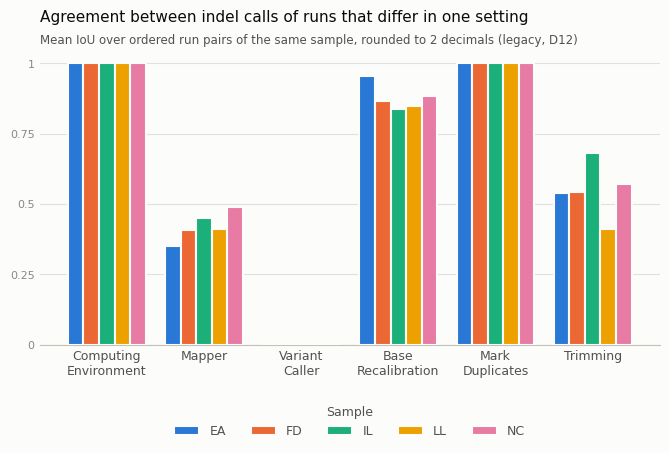

Sample,EA,FD,IL,LL,NC
Parameter,,,,,
Computing Environment,1.000,1.000,1.000,1.000,1.000
Mapper,0.352,0.408,0.451,0.410,0.490
Variant Caller,0.000,0.000,0.002,0.000,0.000
Base Recalibration,0.956,0.868,0.839,0.849,0.884
Mark Duplicates,1.000,1.000,1.000,1.000,1.000
Trimming,0.540,0.544,0.682,0.412,0.570


In [7]:
fig, ax = viz.iou_by_factor_bars(
    grouped, title="Agreement between indel calls of runs that differ in one setting",
    subtitle="Mean IoU over ordered run pairs of the same sample, rounded to 2 decimals (legacy, D12)")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "iou_by_setting"))
plt.show()
# Table view of the same values
grouped.pivot(index="Parameter", columns="Sample", values="mean_iou_2dp").reindex(list(CONTRASTS)).round(3)

## Parity check

The legacy indel pair tables are not kept, so this is a partial check against values the legacy indel notebook printed (`data/derived/legacy_indel_iou_recorded.csv`):
- the run settings equal the legacy metadata, and every set has the size of the legacy filtering count;
- the number of ordered pairs (102,400) and of pairs with the same five settings but another environment (1,600);
- 20 pair values from the head and tail of the pair table (cells 38 and 39);
- the 5 Base Recalibration means (cell 43).

Everything else is reported as not compared. Results are moved out of staging only if every check that ran passes.

In [8]:
recorded = pd.read_csv(config.LEGACY_INDEL_IOU_RECORDED)
labels = metrics.legacy_pair_labels(runs)
assert labels.is_unique
ordered = metrics.ordered_pairs(pairs)  # the legacy table holds both directions
ordered["TestCase1"] = ordered["run_1"].map(labels)
ordered["TestCase2"] = ordered["run_2"].map(labels)

parity = audit.Parity()

# The inputs: settings and set sizes against the legacy metadata and filtering counts
legacy_meta = pd.read_csv(config.LEGACY_META_INDELS)
legacy_meta["TestCaseNo"] = legacy_meta["TestCaseNo"].map(io.canon)
legacy_meta = legacy_meta.set_index("TestCaseNo")
ours = runs.set_index("TestCaseNo")
differs = {c: int((ours[c].astype(str) != legacy_meta[c].reindex(ours.index).astype(str)).sum()) for c in LEVELS}
differs = {c: n for c, n in differs.items() if n}
parity.check("run settings == legacy vcfcomparison_full_indels ({} columns)".format(len(LEVELS)), not differs, differs)
legacy_filtering = pd.read_csv(config.LEGACY_FILTERING_INDELS, dtype={"Key": str}).set_index("Key")
n_variants = pd.Series({k: len(v) for k, v in sets.items()})
n_match = int((n_variants.reindex(legacy_filtering.index) == legacy_filtering["After FilterPass"]).sum())
parity.check("variants per run == legacy filtering_df_indels 'After FilterPass' (every run)",
             n_match == len(legacy_filtering) == EXPECTED_RUNS, "{}/{} match".format(n_match, len(legacy_filtering)))

# Values printed by the legacy indel notebook
def recorded_value(kind):
    return int(recorded.loc[recorded["kind"] == kind, "value"].iloc[0])


parity.check("ordered pairs == rows of the legacy pair table", len(ordered) == recorded_value("n_pairs_all") == n_runs ** 2,
             "{:,} pairs".format(len(ordered)))
first, second = (ordered[c].str.split("/", expand=True) for c in ("TestCase1", "TestCase2"))
same_five = (first.iloc[:, :5] == second.iloc[:, :5]).all(axis=1) & (first[7] != second[7])
parity.check("pairs with the same five settings and another environment == legacy filtered table rows",
             int(same_five.sum()) == recorded_value("n_pairs_same_5_environment_differs"), "{:,} pairs".format(int(same_five.sum())))
recorded_pairs = recorded[recorded["kind"] == "pair"].merge(ordered, on=["TestCase1", "TestCase2"], how="left")
d_pairs = (recorded_pairs["value"] - recorded_pairs["iou_2dp"]).abs()
parity.check("iou_2dp == the {} recorded legacy pair values".format(len(recorded_pairs)),
             recorded_pairs["iou_2dp"].notna().all() and d_pairs.max() <= TOLERANCE, "max |diff| {:.2e}".format(d_pairs.max()))
recorded_means = recorded[recorded["kind"] == "grouped_mean"].rename(columns={"parameter": "Parameter"})
recorded_means = recorded_means.assign(Sample=recorded_means["Sample"].str.upper()).merge(
    grouped, on=["Sample", "Parameter"], how="left")
d_means = (recorded_means["value"] - recorded_means["mean_iou_2dp"]).abs()
parity.check("mean_iou_2dp == the {} recorded legacy grouped means ({})".format(
    len(recorded_means), ", ".join(sorted(set(recorded_means["Parameter"])))),
    recorded_means["mean_iou_2dp"].notna().all() and d_means.max() <= TOLERANCE, "max |diff| {:.2e}".format(d_means.max()))
parity.skip("the rest of the legacy indel pair table ({:,} pairs) and the other {} grouped means".format(
    len(ordered) - len(recorded_pairs), len(grouped) - len(recorded_means)),
    "dfs_indels/*.csv are not in the repository; only the printed values above are compared")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (6 checks, 1 skipped)
PASS  run settings == legacy vcfcomparison_full_indels (7 columns)  [{}]
PASS  variants per run == legacy filtering_df_indels 'After FilterPass' (every run)  [320/320 match]
PASS  ordered pairs == rows of the legacy pair table  [102,400 pairs]
PASS  pairs with the same five settings and another environment == legacy filtered table rows  [1,600 pairs]
PASS  iou_2dp == the 20 recorded legacy pair values  [max |diff| 0.00e+00]
PASS  mean_iou_2dp == the 5 recorded legacy grouped means (Base Recalibration)  [max |diff| 0.00e+00]
SKIP  the rest of the legacy indel pair table (102,380 pairs) and the other 25 grouped means  [dfs_indels/*.csv are not in the repository; only the printed values above are compared]



## Audit summary

In [9]:
by_parameter = grouped.groupby("Parameter", sort=False).agg(
    n_pairs=("n_pairs", "max"), min_mean_iou_2dp=("mean_iou_2dp", "min"), max_mean_iou_2dp=("mean_iou_2dp", "max"))
lines = [
    "runs: {}; unordered pairs, self-pairs included: {:,}; ordered pairs: {:,}".format(n_runs, len(pairs), len(ordered)),
    "indel sets: read from the legacy cache {}, not re-parsed from VCFs".format(
        config.LEGACY_SETS_INDELS.relative_to(config.REPO_ROOT).as_posix()),
    "compared with legacy: {} recorded pair values (max |diff| {:.1e}), {} recorded grouped means (max |diff| {:.1e}),".format(
        len(recorded_pairs), d_pairs.max(), len(recorded_means), d_means.max()),
    "  pair counts; NOT compared: the rest of the pair table and {} of the {} grouped means (legacy tables not kept)".format(
        len(grouped) - len(recorded_means), len(grouped)),
    "Result VCF Count is empty for the indel runs; legacy count used: filtering_df_indels 'After FilterPass'",
    "phase is empty for {} of {} runs (not used)".format(int(runs["phase"].isna().sum()), n_runs),
    "",
    "rounding to 2 decimals (D12, undecided): largest change of a pair {:.4f}, of a grouped mean {:.4f}".format(
        (pairs["iou"] - pairs["iou_2dp"]).abs().max(), (grouped["mean_iou"] - grouped["mean_iou_2dp"]).abs().max()),
    "",
    "grouped mean IoU (2 decimals) by parameter, range over the {} samples; n_pairs = ordered pairs per sample:".format(
        len(LEVELS["Sample"])),
    by_parameter.to_string(),
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 320; unordered pairs, self-pairs included: 51,360; ordered pairs: 102,400
indel sets: read from the legacy cache data/derived/sets_dict_indels.csv, not re-parsed from VCFs
compared with legacy: 20 recorded pair values (max |diff| 0.0e+00), 5 recorded grouped means (max |diff| 0.0e+00),
  pair counts; NOT compared: the rest of the pair table and 25 of the 30 grouped means (legacy tables not kept)
Result VCF Count is empty for the indel runs; legacy count used: filtering_df_indels 'After FilterPass'
phase is empty for 64 of 320 runs (not used)

rounding to 2 decimals (D12, undecided): largest change of a pair 0.0050, of a grouped mean 0.0015

grouped mean IoU (2 decimals) by parameter, range over the 5 samples; n_pairs = ordered pairs per sample:
                       n_pairs  min_mean_iou_2dp  max_mean_iou_2dp
Parameter                                                         
Computing Environment       64           1.00000           1.00000
Mapper                      64        